# Loan Data - Visualization & Analytics Notebook

This notebook focuses purely on **exploring and analyzing** the loan dataset through
visualizations and summary statistics. It complements the main
`Credit_Risk_Scoring.ipynb` notebook, which covers the full modeling pipeline.

Here we go a bit deeper into the data with grouped summaries, additional charts,
and analytical insights that support the model-building decisions made in the
main notebook.

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

# Load dataset
df = pd.read_csv("loan_data.csv")
df.head()


,Age,Income,LoanAmount,CreditScore,EmploymentStatus,LoanTerm,PreviousDefaults,DebtToIncomeRatio,MaritalStatus,Education,Default
0,54,48314.06,10689.27,576.0,Unemployed,36,1,0.35,Single,Masters,0
1,36,44622.81,10249.51,747.0,Employed,36,0,0.45,Single,High School,0
2,30,58067.49,29370.89,597.0,Employed,24,0,0.34,Divorced,High School,1
3,56,64779.36,25230.93,547.0,Employed,24,0,0.15,Single,High School,0
4,53,56730.17,17798.40,593.0,Self-Employed,48,2,0.41,Single,Masters,1


In [2]:
# Basic cleanup so charts and summaries aren't skewed by missing values/duplicates
df = df.drop_duplicates()

for col in ["Income", "CreditScore", "DebtToIncomeRatio"]:
    df[col] = df[col].fillna(df[col].median())

df["EmploymentStatus"] = df["EmploymentStatus"].fillna(df["EmploymentStatus"].mode()[0])

print("Shape after cleanup:", df.shape)
df.isnull().sum()


Shape after cleanup: (1000, 11)


Age                  0
Income               0
LoanAmount           0
CreditScore          0
EmploymentStatus     0
LoanTerm             0
PreviousDefaults     0
DebtToIncomeRatio    0
MaritalStatus        0
Education            0
Default              0
dtype: int64

## 2. Overall Default Rate

Overall loan default rate: 37.80%


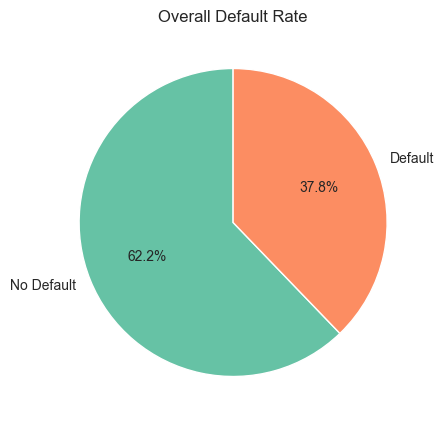

In [3]:
default_rate = df["Default"].mean() * 100
print(f"Overall loan default rate: {default_rate:.2f}%")

plt.figure(figsize=(5,5))
df["Default"].value_counts().plot.pie(
    labels=["No Default", "Default"],
    autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"],
    startangle=90
)
plt.title("Overall Default Rate")
plt.ylabel("")
plt.show()


**Insight:** Roughly a third of customers in this dataset defaulted on their loan, giving us a reasonably balanced target for analysis (not extremely rare-event data).

## 3. Default Rate by Employment Status

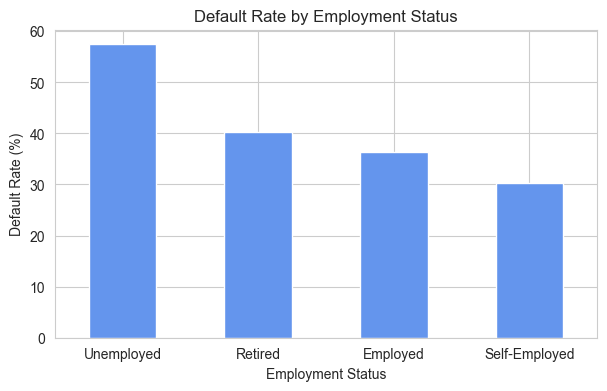

EmploymentStatus
Unemployed       57.425743
Retired          40.243902
Employed         36.434109
Self-Employed    30.232558
Name: Default, dtype: float64

In [4]:
emp_default = df.groupby("EmploymentStatus")["Default"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7,4))
emp_default.plot(kind="bar", color="cornflowerblue")
plt.title("Default Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

emp_default


**Insight:** Unemployed customers show a noticeably higher default rate compared to employed or retired customers, suggesting employment stability is a relevant risk factor.

## 4. Default Rate by Education Level

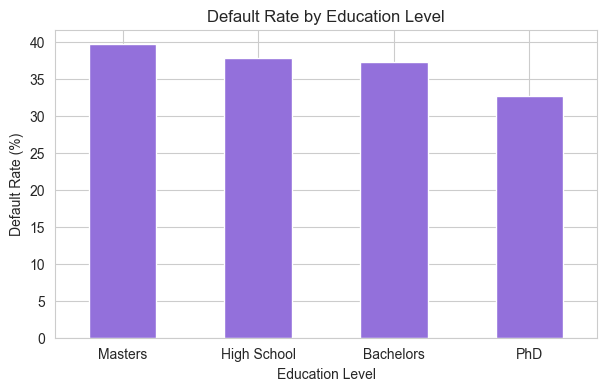

Education
Masters        39.615385
High School    37.800687
Bachelors      37.250000
PhD            32.653061
Name: Default, dtype: float64

In [5]:
edu_default = df.groupby("Education")["Default"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7,4))
edu_default.plot(kind="bar", color="mediumpurple")
plt.title("Default Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

edu_default


**Insight:** Default rates vary somewhat across education levels, though the differences are less pronounced than for employment status or credit history.

## 5. Loan Amount vs Income (Scatter Plot)

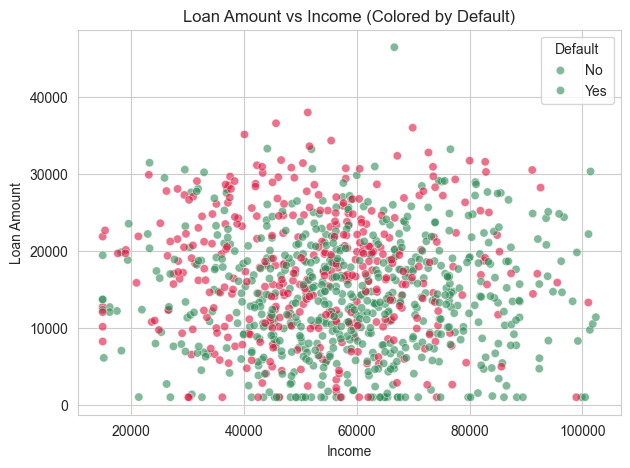

In [6]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="Income", y="LoanAmount", hue="Default",
    data=df, palette={0: "seagreen", 1: "crimson"}, alpha=0.6
)
plt.title("Loan Amount vs Income (Colored by Default)")
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.legend(title="Default", labels=["No", "Yes"])
plt.show()


**Insight:** There isn't a single sharp boundary between defaulters and non-defaulters based on income and loan amount alone — defaults are scattered across the income range, reinforcing that multiple features together (like credit score and previous defaults) matter more than income or loan size alone.

## 6. Debt-to-Income Ratio Distribution by Default

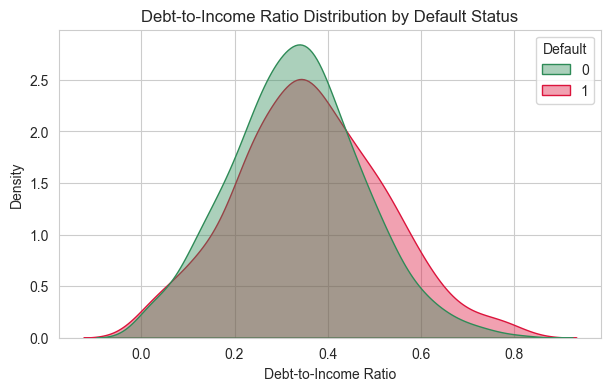

In [7]:
plt.figure(figsize=(7,4))
sns.kdeplot(data=df, x="DebtToIncomeRatio", hue="Default", fill=True,
            palette={0: "seagreen", 1: "crimson"}, common_norm=False, alpha=0.4)
plt.title("Debt-to-Income Ratio Distribution by Default Status")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Density")
plt.show()


**Insight:** Customers who default tend to have a debt-to-income ratio distribution shifted to the right, meaning they typically carry more debt relative to their income than customers who repay successfully.

## 7. Credit Score by Marital Status (Boxplot)

C:\Users\rudra\AppData\Local\Temp\ipykernel_18036\3376531793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="MaritalStatus", y="CreditScore", data=df, palette="pastel")


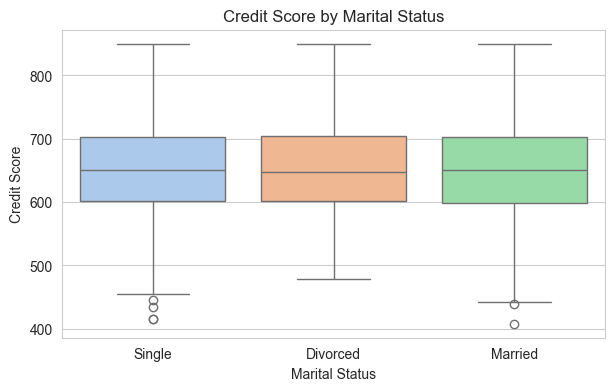

In [8]:
plt.figure(figsize=(7,4))
sns.boxplot(x="MaritalStatus", y="CreditScore", data=df, palette="pastel")
plt.title("Credit Score by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Credit Score")
plt.show()


**Insight:** Credit score distributions are broadly similar across marital status groups, suggesting this feature is a weaker standalone predictor of credit risk compared to credit score or previous defaults.

## 8. Loan Term Analysis

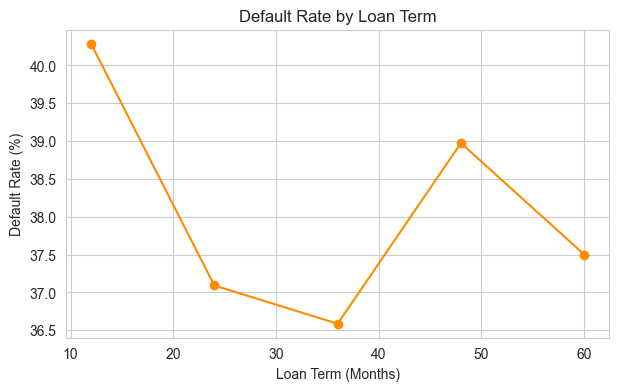

LoanTerm
12    40.287770
24    37.090909
36    36.585366
48    38.974359
60    37.500000
Name: Default, dtype: float64

In [9]:
term_default = df.groupby("LoanTerm")["Default"].mean().sort_index() * 100

plt.figure(figsize=(7,4))
term_default.plot(kind="line", marker="o", color="darkorange")
plt.title("Default Rate by Loan Term")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Default Rate (%)")
plt.grid(True)
plt.show()

term_default


**Insight:** Default rate shows some variation across loan terms, which can help inform lending policy around recommended loan durations for higher-risk applicants.

## 9. Summary Table: Average Metrics by Default Status

In [10]:
summary = df.groupby("Default")[["Age", "Income", "LoanAmount", "CreditScore",
                                     "PreviousDefaults", "DebtToIncomeRatio"]].mean().round(2)
summary.index = ["No Default", "Default"]
summary


,Age,Income,LoanAmount,CreditScore,PreviousDefaults,DebtToIncomeRatio
No Default,42.78,59097.24,13893.43,671.50,0.39,0.33
Default,43.37,52750.27,17258.52,617.45,0.81,0.36


## 10. Analytics Summary

- **Default rate:** Roughly one in three customers in this dataset defaulted on their loan.
- **Credit Score:** Customers who defaulted have a lower average credit score.
- **Previous Defaults:** Customers who defaulted have, on average, more previous defaults.
- **Debt-to-Income Ratio:** Higher debt-to-income ratios are associated with higher default rates.
- **Employment Status:** Unemployed customers default at a noticeably higher rate.
- **Income & Loan Amount:** These alone don't cleanly separate defaulters from
  non-defaulters, supporting the use of multiple combined features in the predictive model.

These analytical findings directly support the feature importance results seen in the
main modeling notebook (`Credit_Risk_Scoring.ipynb`), where Credit Score and Previous
Defaults emerged as the top predictors of loan default.
